# Shared Significant-Gene GO Enrichment (Mode B Only)

This notebook uses strict shared-significant intersection across subtypes:

1. Select significant genes per subtype (`pvalue < 0.05` and `|log2FC| > 1`).
2. Intersect those significant sets across all subtypes.
3. Run GO enrichment for combined shared-significant genes.
4. Run GO enrichment split into shared upregulated and shared downregulated genes.

In [1]:
import sys
sys.path.append("../src")

import importlib
import pandas as pd
import GOenrichment as ge

importlib.reload(ge)

files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv",
}

MODE B: Strict shared-significant intersection
Combined shared-significant genes: 3005
Shared up genes: 1601
Shared down genes: 1404


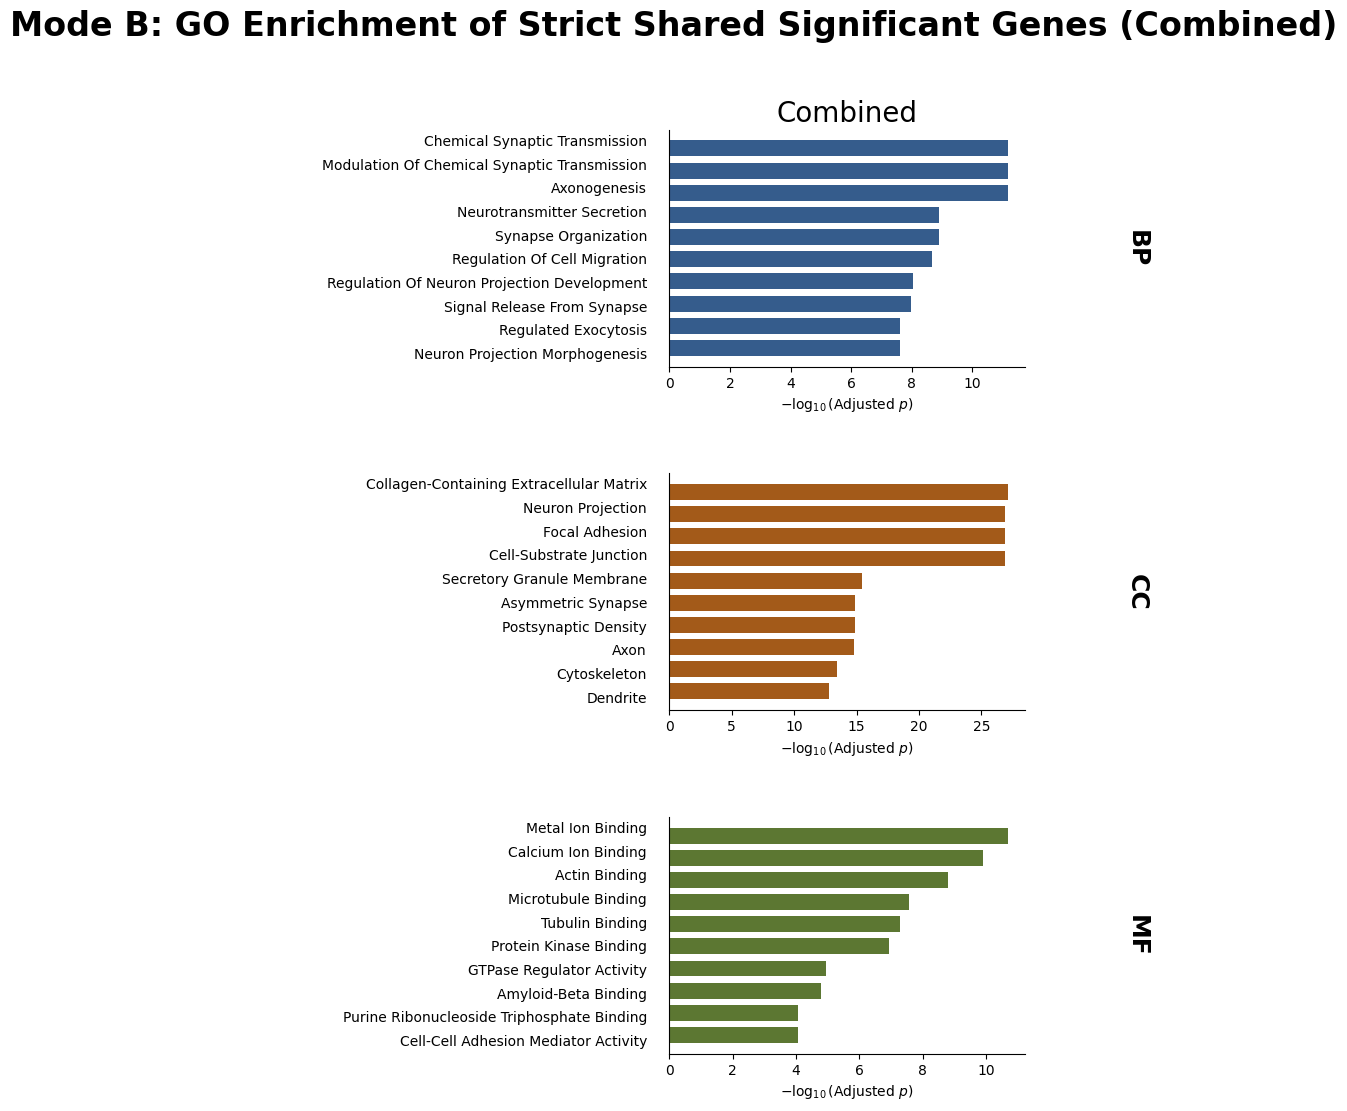

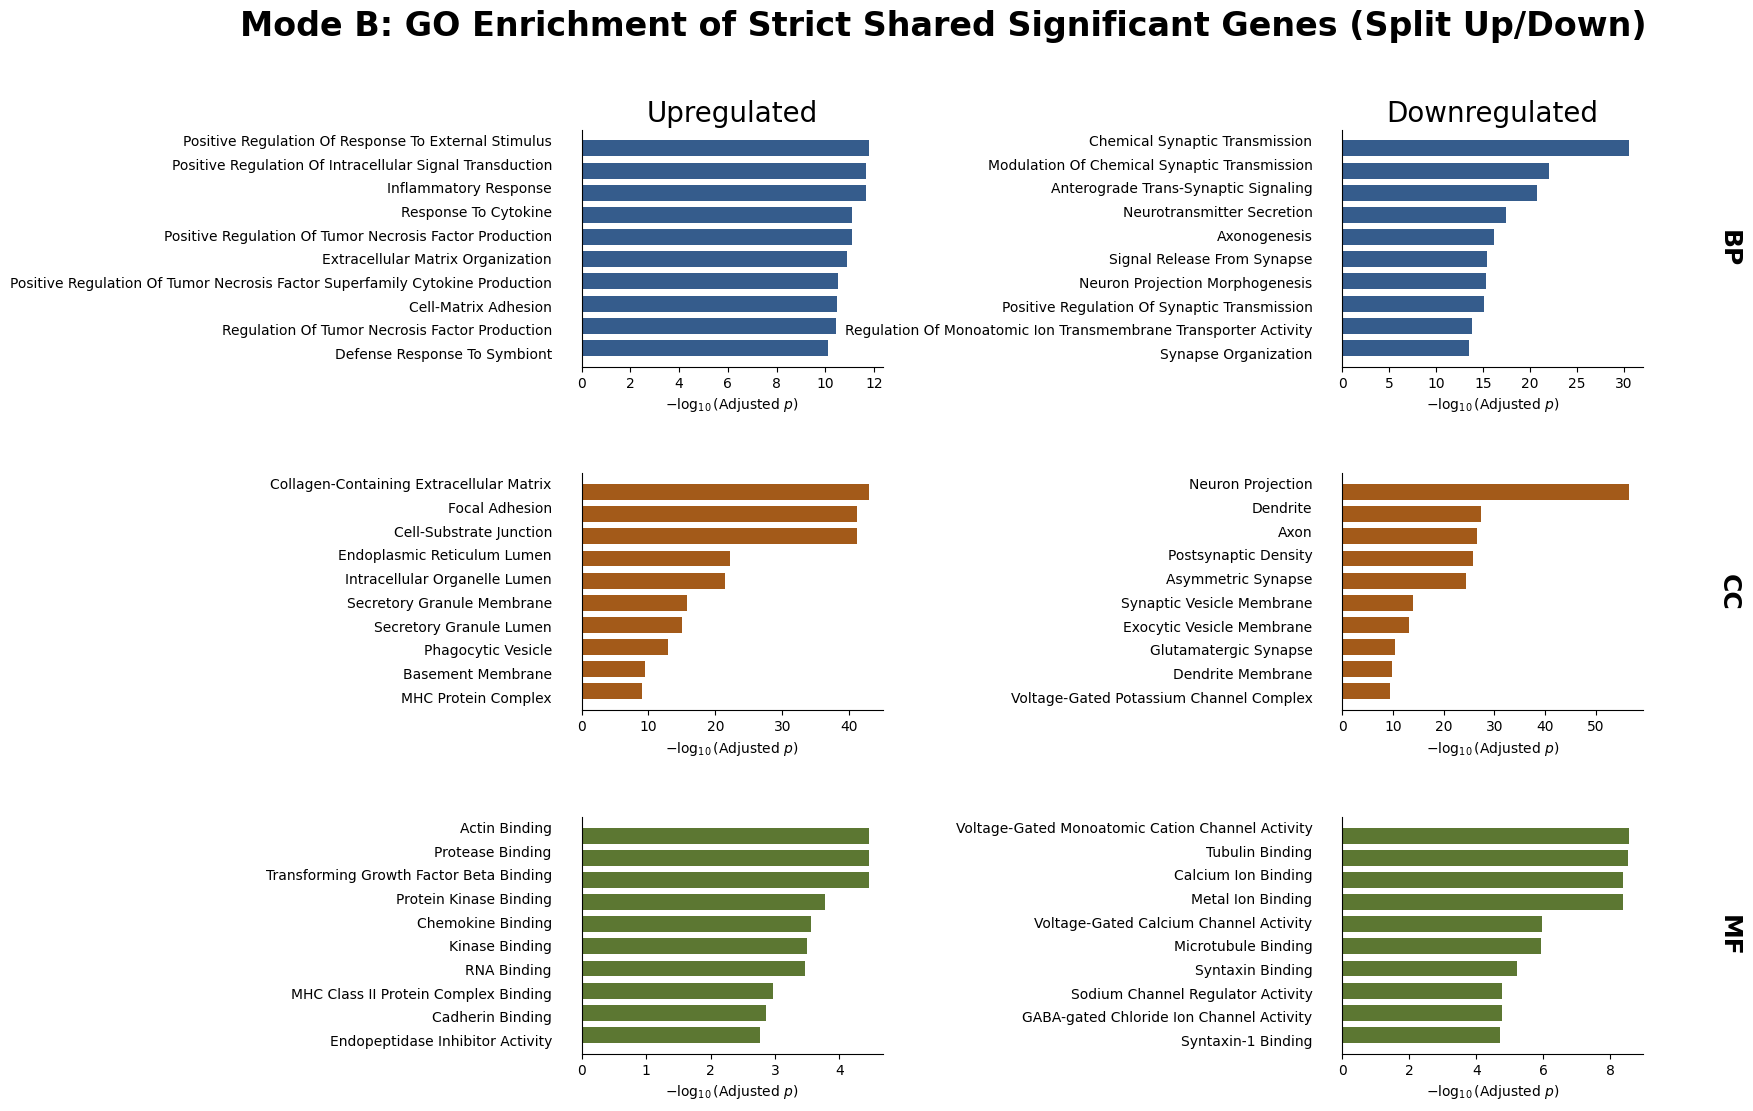

In [2]:
sig_up_sets = {}
sig_down_sets = {}

for subtype, file in files.items():
    df = pd.read_csv(file)

    up = df[
        (df[ge.PVAL_COLUMN] < ge.PVAL_THRESHOLD)
        &
        (df[ge.LOGFC_COLUMN] > ge.LOGFC_THRESHOLD)
    ]
    down = df[
        (df[ge.PVAL_COLUMN] < ge.PVAL_THRESHOLD)
        &
        (df[ge.LOGFC_COLUMN] < -ge.LOGFC_THRESHOLD)
    ]

    sig_up_sets[subtype] = set(
        up[ge.GENE_COLUMN].dropna().str.upper()
    )
    sig_down_sets[subtype] = set(
        down[ge.GENE_COLUMN].dropna().str.upper()
    )

shared_up_genes = set.intersection(*sig_up_sets.values())
shared_down_genes = set.intersection(*sig_down_sets.values())

combined_genes = sorted(shared_up_genes | shared_down_genes)
up_genes = sorted(shared_up_genes)
down_genes = sorted(shared_down_genes)

print("MODE B: Strict shared-significant intersection")
print("Combined shared-significant genes:", len(combined_genes))
print("Shared up genes:", len(up_genes))
print("Shared down genes:", len(down_genes))

go_combined = {}
go_up = {}
go_down = {}

for ontology, library in ge.GO_LIBRARIES.items():
    go_combined[ontology] = ge.run_go(combined_genes, library)
    go_up[ontology] = ge.run_go(up_genes, library)
    go_down[ontology] = ge.run_go(down_genes, library)

ge.plot_go(
    go_combined,
    title="Mode B: GO Enrichment of Strict Shared Significant Genes (Combined)",
)

ge.plot_go(
    go_up,
    go_down,
    title="Mode B: GO Enrichment of Strict Shared Significant Genes (Split Up/Down)",
)